Clusters trouves : 2
Points de bruit : 0


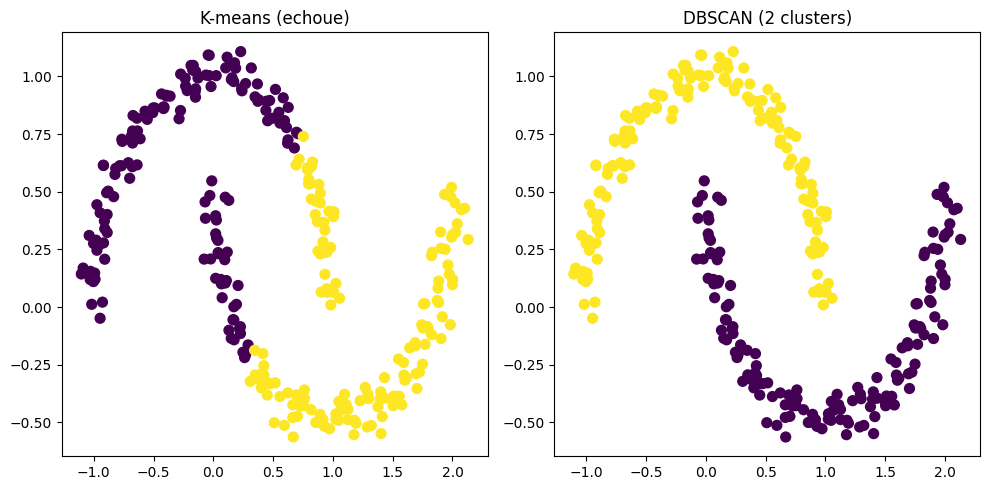

In [ ]:
# Import des librairies
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons

# Generation de donnees non-spheriques
X, y_true = make_moons(n_samples=300, noise=0.05, random_state=42)

# Application de DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
y_pred = dbscan.fit_predict(X)

# Nombre de clusters trouves et points de bruit
n_clusters = len(set(y_pred)) - (1 if -1 in y_pred else 0)
n_noise = list(y_pred).count(-1)
print(f"Clusters trouves : {n_clusters}")
print(f"Points de bruit : {n_noise}")

# Visualisation
plt.figure(figsize=(10, 5))

# Comparaison K-means vs DBSCAN
plt.subplot(1, 2, 1)
from sklearn.cluster import KMeans
kmeans_pred = KMeans(n_clusters=2, random_state=42).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=kmeans_pred, cmap='viridis', s=50)
plt.title('K-means (echoue)')

plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=50)
plt.title(f'DBSCAN ({n_clusters} clusters)')
plt.tight_layout()
plt.show()

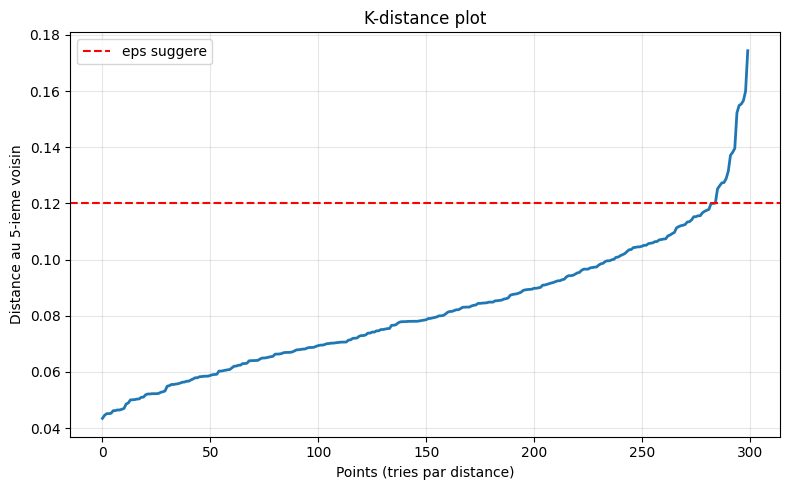

In [3]:
# K-distance plot pour estimer eps
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# Calculer la distance au k-ieme voisin le plus proche
k = 5  # k = min_samples
nn = NearestNeighbors(n_neighbors=k)
nn.fit(X)
distances, indices = nn.kneighbors(X)

# Trier les distances au k-ieme voisin
k_distances = np.sort(distances[:, k-1])

# Tracer le k-distance plot
plt.figure(figsize=(8, 5))
plt.plot(k_distances, linewidth=2)
plt.xlabel('Points (tries par distance)')
plt.ylabel(f'Distance au {k}-ieme voisin')
plt.title('K-distance plot')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.12, color='r', linestyle='--', label='eps suggere')
plt.legend()
plt.tight_layout()
plt.show()